# 🔐 AI-Powered Financial Fraud Detection System

### Machine Learning + NLP Based Fraud Detection Project

---

## 📌 Project Overview

This project demonstrates an end-to-end financial fraud detection workflow using **Machine Learning and Natural Language Processing (NLP)**.

The system analyzes transaction information such as **transaction amount, transaction time, account history, device information, transaction type, location, and transaction description** to identify potentially fraudulent transactions.

> **Note:** The dataset used in this project is simulated and created for educational/prototype purposes. This project is not intended to represent a production banking system.

---

## 🎯 Project Objectives

- Understand and explore financial transaction data
- Perform Exploratory Data Analysis (EDA)
- Apply numerical and categorical preprocessing
- Convert transaction descriptions into numerical features using **TF-IDF**
- Train and compare multiple Machine Learning classification models
- Evaluate models using **Accuracy, Precision, Recall, F1-Score and ROC-AUC**
- Analyze feature importance
- Test the trained model on new transactions

---

## 🛠️ Technology Stack

**Python | Pandas | NumPy | Scikit-learn | Matplotlib | NLP | TF-IDF | Machine Learning**

---

## 1. Import Required Libraries

We use Pandas and NumPy for data handling, Matplotlib for visualization, and Scikit-learn for preprocessing, NLP, model training, and evaluation.

In [3]:
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Create a Simulated Financial Transaction Dataset

For this educational project, we create 10,000 simulated transactions.

A real fraud detection system should use a representative real-world dataset. The simulated data is useful here because it lets us demonstrate the complete workflow without requiring sensitive banking data.

In [4]:
# Create a simulated financial transaction dataset

np.random.seed(42)
n_samples = 10000

transaction_types = ["Purchase", "Transfer", "Withdrawal", "Payment"]
locations = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata"]
devices = ["Android", "iOS", "Windows", "Mac"]

# Generate transaction features
amount = np.random.uniform(100, 100000, n_samples)
transaction_hour = np.random.randint(0, 24, n_samples)
international = np.random.binomial(1, 0.08, n_samples)
previous_transactions = np.random.randint(0, 20, n_samples)
account_age_days = np.random.randint(30, 3000, n_samples)
failed_attempts = np.random.poisson(0.5, n_samples).clip(0, 5)
new_device = np.random.binomial(1, 0.15, n_samples)

transaction_type = np.random.choice(
    transaction_types, n_samples
)

location = np.random.choice(
    locations, n_samples
)

device = np.random.choice(
    devices, n_samples
)

# Create a fraud score from transaction characteristics
fraud_score = (
    (amount > 70000).astype(int) * 2
    + (amount > 90000).astype(int)
    + (transaction_hour <= 4).astype(int) * 2
    + international * 2
    + (failed_attempts >= 3).astype(int) * 2
    + new_device * 2
    + (account_age_days < 120).astype(int)
)

# Convert fraud score into a probability and generate the fraud label
fraud_probability = 1 / (1 + np.exp(-(fraud_score - 5.5)))
fraud = np.random.binomial(1, fraud_probability)

# Generate transaction descriptions independently of the fraud label
transaction_descriptions = [
    "purchase transaction",
    "online shopping transaction",
    "salary payment",
    "cash withdrawal",
    "bill payment",
    "account transfer",
    "card payment",
    "utility payment",
    "mobile payment",
    "online transfer"
]

description = np.random.choice(
    transaction_descriptions,
    size=n_samples
)

# Create the final dataset
data = pd.DataFrame({
    "amount": amount,
    "transaction_hour": transaction_hour,
    "international": international,
    "previous_transactions": previous_transactions,
    "account_age_days": account_age_days,
    "failed_attempts": failed_attempts,
    "new_device": new_device,
    "transaction_type": transaction_type,
    "location": location,
    "device": device,
    "description": description,
    "fraud": fraud
})

print("Dataset created successfully!")
print("Dataset shape:", data.shape)
display(data.head())

Dataset created successfully!
Dataset shape: (10000, 12)


,amount,transaction_hour,international,previous_transactions,account_age_days,failed_attempts,new_device,transaction_type,location,device,description,fraud
0,37516.557873,22,0,4,1375,2,1,Payment,Bangalore,Android,account transfer,0
1,95076.359210,3,0,19,1998,1,1,Withdrawal,Delhi,Windows,purchase transaction,0
2,73226.194787,17,0,11,1415,0,0,Payment,Kolkata,Windows,utility payment,0
3,59905.982571,4,1,19,2647,1,1,Transfer,Chennai,Windows,mobile payment,0
4,15686.262180,15,0,19,1984,2,0,Transfer,Mumbai,iOS,mobile payment,0


## 3. Data Understanding

Before modeling, we inspect the dataset structure, data types, missing values, and class distribution.

In [5]:
print("Dataset Shape:")
print(data.shape)

print("\nColumn Names:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

print("\nFraud Class Distribution:")
print(data["fraud"].value_counts().rename(index={0: "Legitimate", 1: "Fraud"}))

print(f"\nFraudulent Transactions: {data['fraud'].mean() * 100:.2f}%")

Dataset Shape:
(10000, 12)

Column Names:
['amount', 'transaction_hour', 'international', 'previous_transactions', 'account_age_days', 'failed_attempts', 'new_device', 'transaction_type', 'location', 'device', 'description', 'fraud']

Data Types:
amount                   float64
transaction_hour           int32
international              int32
previous_transactions      int32
account_age_days           int32
failed_attempts            int32
new_device                 int32
transaction_type             str
location                     str
device                       str
description                  str
fraud                      int32
dtype: object

Missing Values:
amount                   0
transaction_hour         0
international            0
previous_transactions    0
account_age_days         0
failed_attempts          0
new_device               0
transaction_type         0
location                 0
device                   0
description              0
fraud                    0
dt

## 4. Exploratory Data Analysis (EDA)

EDA helps us understand patterns in the transactions before training the model.

We will examine:

1. Legitimate vs. fraudulent transaction counts.
2. Transaction amount distribution.
3. Fraud distribution across transaction hours.
4. Average transaction amount by fraud class.

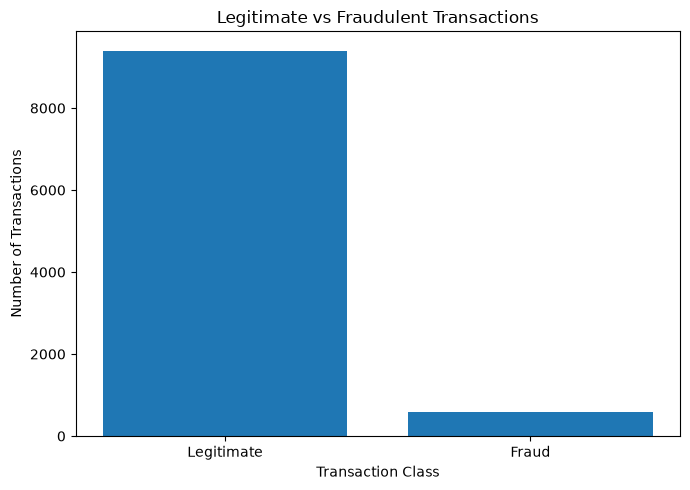

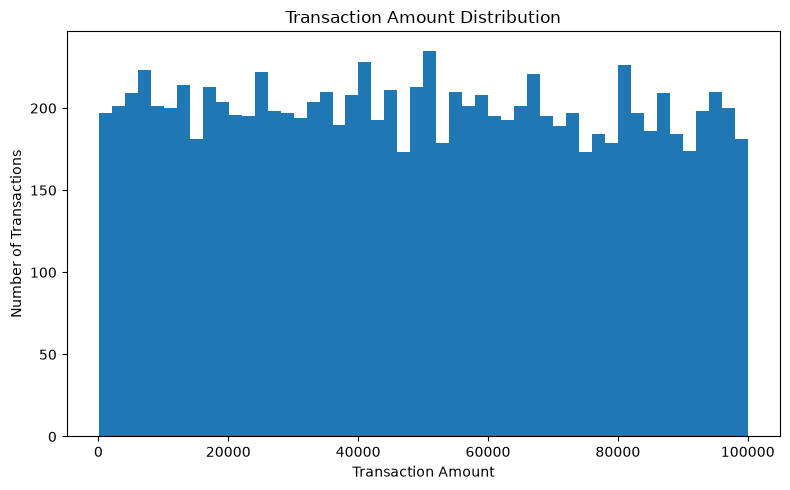

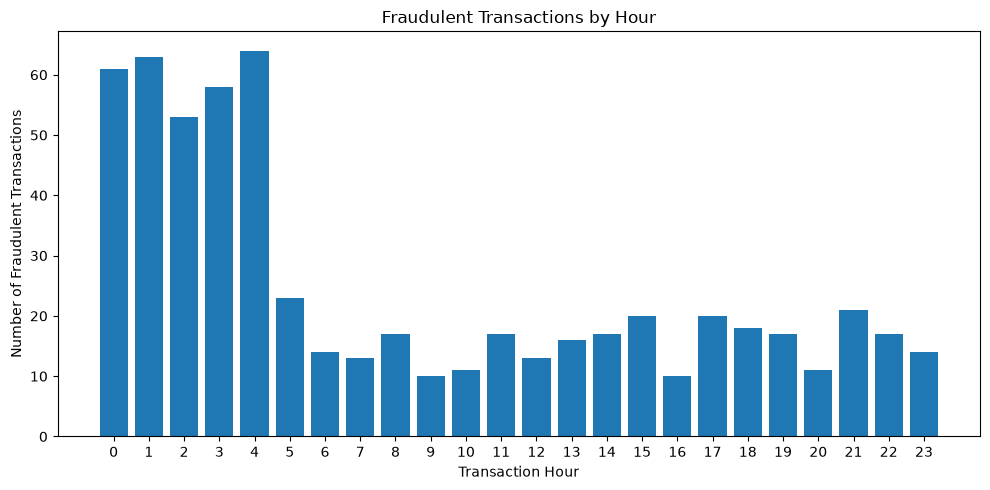

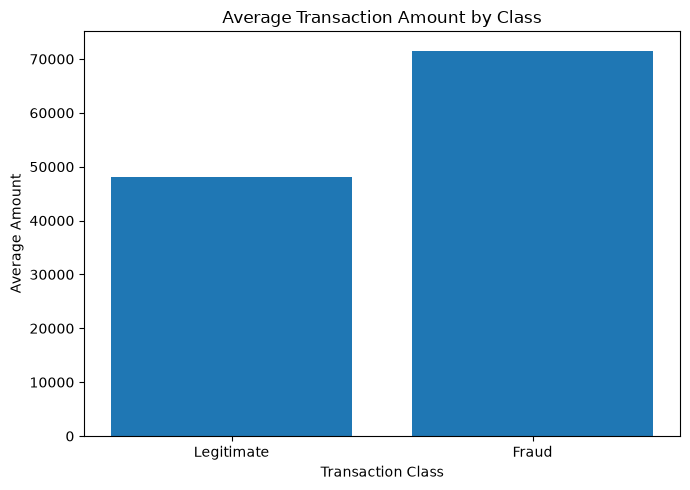

In [6]:
# 4.1 Legitimate vs Fraudulent Transactions
class_counts = data["fraud"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], [class_counts.get(0, 0), class_counts.get(1, 0)])
plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# 4.2 Transaction Amount Distribution
plt.figure(figsize=(8, 5))
plt.hist(data["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# 4.3 Fraud Count by Transaction Hour
hour_fraud = data.groupby("transaction_hour")["fraud"].sum()

plt.figure(figsize=(10, 5))
plt.bar(hour_fraud.index, hour_fraud.values)
plt.title("Fraudulent Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Fraudulent Transactions")
plt.xticks(range(24))
plt.tight_layout()
plt.show()

# 4.4 Average Amount by Class
avg_amount = data.groupby("fraud")["amount"].mean()

plt.figure(figsize=(7, 5))
plt.bar(["Legitimate", "Fraud"], [avg_amount.get(0, 0), avg_amount.get(1, 0)])
plt.title("Average Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Average Amount")
plt.tight_layout()
plt.show()

### EDA Interpretation

The charts help us see whether transaction amount, transaction timing, and other behavioral patterns differ between legitimate and fraudulent transactions.

Because this dataset is simulated, these patterns are **illustrative rather than evidence about real banking behavior**. In a real project, conclusions should be based on a validated public or organizational dataset.

## 5. Train-Test Split

We split the raw data **before fitting any preprocessing or NLP transformer**. This is important because fitting preprocessing on the entire dataset can cause **data leakage** from the test set into training.

- **80% training data:** used to learn patterns.
- **20% testing data:** kept unseen until evaluation.

Stratification keeps the fraud/legitimate class ratio approximately consistent between the two sets.

In [7]:
train_df, test_df = train_test_split(
    data,
    test_size=0.20,
    random_state=42,
    stratify=data["fraud"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

y_train = train_df["fraud"]
y_test = test_df["fraud"]

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training class distribution:
fraud
0    7522
1     478
Name: count, dtype: int64

Testing class distribution:
fraud
0    1880
1     120
Name: count, dtype: int64


## 6. Text Cleaning and NLP with TF-IDF

Transaction descriptions are text. Machine Learning models need numerical representations, so we clean the text and convert it into TF-IDF features.

**TF-IDF** gives higher importance to useful words while reducing the influence of very common words.

The vectorizer is fitted **only on training text** to avoid test-set leakage.

In [8]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_text = train_df["description"].apply(clean_text)
test_text = test_df["description"].apply(clean_text)

tfidf = TfidfVectorizer(
    max_features=100,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

print("NLP vectorization completed!")
print("Training text features:", X_train_text.shape)
print("Testing text features:", X_test_text.shape)

NLP vectorization completed!
Training text features: (8000, 23)
Testing text features: (2000, 23)


## 7. Numerical and Categorical Preprocessing

We have three feature groups:

- **Numerical:** amount, transaction hour, account age, failed attempts, etc.
- **Categorical:** transaction type, location, and device.
- **Text:** transaction description represented using TF-IDF.

Numerical scaling and categorical encoding are fitted only on the training data.

In [9]:
numeric_columns = [
    "amount",
    "transaction_hour",
    "international",
    "previous_transactions",
    "account_age_days",
    "failed_attempts",
    "new_device"
]

categorical_columns = [
    "transaction_type",
    "location",
    "device"
]

scaler = StandardScaler()

X_train_numeric = scaler.fit_transform(
    train_df[numeric_columns]
)

X_test_numeric = scaler.transform(
    test_df[numeric_columns]
)

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_categorical = encoder.fit_transform(
    train_df[categorical_columns]
)

X_test_categorical = encoder.transform(
    test_df[categorical_columns]
)

print("Numerical features:", len(numeric_columns))
print("Categorical features:", X_train_categorical.shape[1])
print("Text features:", X_train_text.shape[1])

Numerical features: 7
Categorical features: 13
Text features: 23


## 8. Combine All Features

We now combine numerical, categorical, and NLP features into one matrix for the Random Forest model.

In [11]:
X_train = hstack([
    csr_matrix(X_train_numeric),
    X_train_categorical,
    X_train_text
]).tocsr()

X_test = hstack([
    csr_matrix(X_test_numeric),
    X_test_categorical,
    X_test_text
]).tocsr()

print("Final training feature matrix:", X_train.shape)
print("Final testing feature matrix:", X_test.shape)

Final training feature matrix: (8000, 43)
Final testing feature matrix: (2000, 43)


## 9. Train the Random Forest Model

Random Forest is an ensemble classification algorithm that combines multiple decision trees.

It is used to learn patterns from the transaction features and classify transactions as legitimate or fraudulent.

In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest model...")
model.fit(X_train, y_train)
print("Model training completed successfully!")

Training Random Forest model...
Model training completed successfully!


## 10. Train the Decision Tree Model

Decision Tree is a tree-based classification algorithm used to classify financial transactions as legitimate or fraudulent.

The model is regularized using depth and minimum sample constraints to reduce overfitting.

In [13]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

print("Training Decision Tree model...")

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed successfully!")

Training Decision Tree model...
Decision Tree training completed successfully!


## 11. Train the KNN Model

K-Nearest Neighbors (KNN) is a distance-based classification algorithm.

It classifies a transaction based on the similarity between the transaction and its nearest training examples.

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)

print("Training KNN model...")

knn_model.fit(X_train, y_train)

print("KNN training completed successfully!")

Training KNN model...
KNN training completed successfully!


## 12. Model Evaluation and Comparison

The three trained models are evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

These metrics provide a balanced view of model performance, especially for fraud detection where identifying fraudulent transactions is important.

The models compared are:
- Random Forest
- Decision Tree
- KNN

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Predictions
rf_pred = model.predict(X_test)
dt_pred = decision_tree_model.predict(X_test)
knn_pred = knn_model.predict(X_test)

# Probability scores for ROC-AUC
rf_prob = model.predict_proba(X_test)[:, 1]
dt_prob = decision_tree_model.predict_proba(X_test)[:, 1]
knn_prob = knn_model.predict_proba(X_test)[:, 1]

# Model evaluation function
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

# Compare models
results = pd.DataFrame([
    evaluate_model("Random Forest", y_test, rf_pred, rf_prob),
    evaluate_model("Decision Tree", y_test, dt_pred, dt_prob),
    evaluate_model("KNN", y_test, knn_pred, knn_prob)
])

results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9255,0.3821,0.3917,0.3868,0.8825
1,Decision Tree,0.8000,0.1818,0.6667,0.2857,0.7283
2,KNN,0.9390,0.4167,0.0417,0.0758,0.7182


## 13. Model Performance Visualization

The performance of Random Forest, Decision Tree, and KNN is visualized using the main evaluation metrics.

This visualization makes it easier to compare the models and identify their strengths and weaknesses.

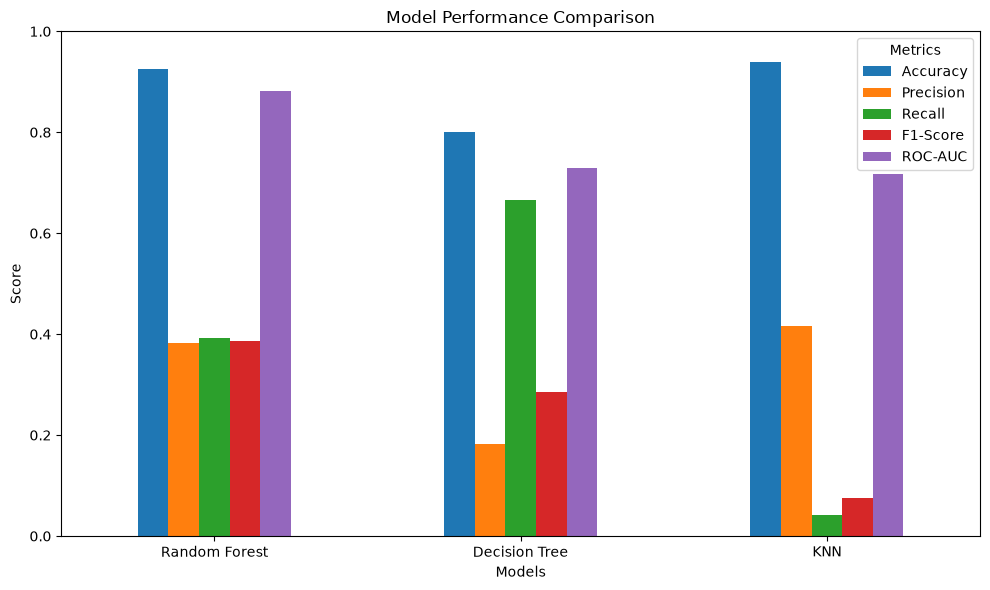

In [16]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

## 14. Random Forest Classification Report and Confusion Matrix

The classification report provides Precision, Recall, and F1-Score for each class.

The confusion matrix shows the number of:
- True Negatives
- False Positives
- False Negatives
- True Positives

These results help evaluate how effectively the final Random Forest model identifies fraudulent transactions.

              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      1880
       Fraud       0.38      0.39      0.39       120

    accuracy                           0.93      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.93      0.93      0.93      2000



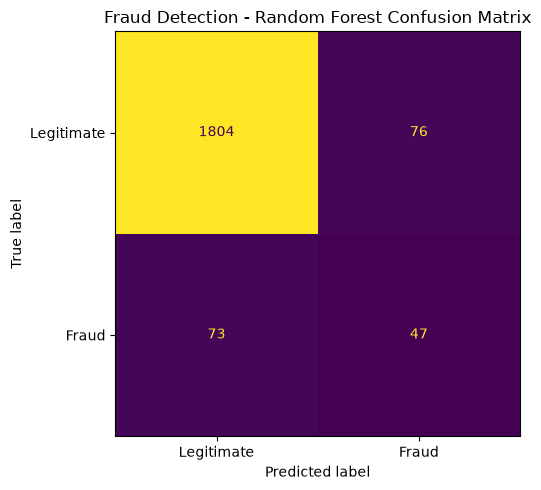

In [19]:
# Random Forest predictions
rf_pred = model.predict(X_test)

# Classification Report
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
).plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Fraud Detection - Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

# 15. Final Model Selection

Based on the model comparison, Random Forest is selected as the overall best-performing model.

It provides the best balance of F1-Score and ROC-AUC among the evaluated models, making it the most suitable model for this fraud detection system.

In [20]:
best_model = results.loc[results["F1-Score"].idxmax(), "Model"]

print("Selected Best Model:", best_model)
display(results.round(4))

Selected Best Model: Random Forest


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9255,0.3821,0.3917,0.3868,0.8825
1,Decision Tree,0.8000,0.1818,0.6667,0.2857,0.7283
2,KNN,0.9390,0.4167,0.0417,0.0758,0.7182


# 16. Feature Importance

Feature importance shows which input features contributed most to the Random Forest model's predictions.

It helps interpret the model and understand the factors that are most useful for identifying fraudulent transactions.

,Feature,Importance
0,amount,0.258972
1,transaction_hour,0.149927
4,account_age_days,0.087737
6,new_device,0.087003
2,international,0.062674
3,previous_transactions,0.062325
5,failed_attempts,0.029198
31,payment,0.018471
19,device_iOS,0.011823
12,location_Chennai,0.011767


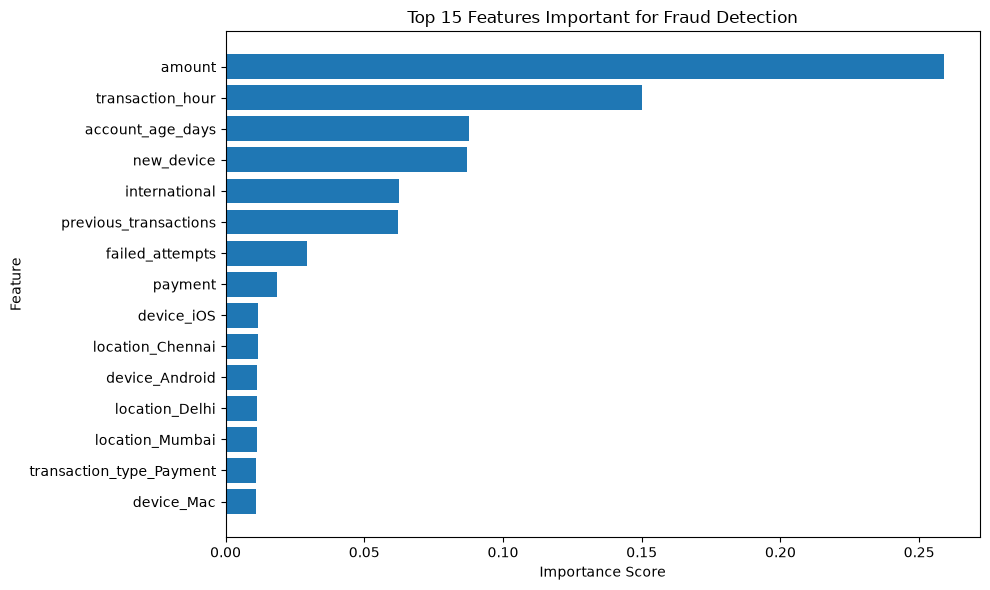

In [21]:
categorical_feature_names = list(
    encoder.get_feature_names_out(categorical_columns)
)
text_feature_names = list(
    tfidf.get_feature_names_out()
)

feature_names = (
    numeric_columns
    + categorical_feature_names
    + text_feature_names
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

top_features = importance_df.head(15)

display(top_features)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.title("Top 15 Features Important for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 17. Live Fraud Prediction

This section defines a function to predict whether a new transaction is legitimate or fraudulent.

The function applies the same preprocessing steps used during model training before generating the prediction.

In [25]:
def predict_transaction(
    amount,
    transaction_hour,
    international,
    previous_transactions,
    account_age_days,
    failed_attempts,
    new_device,
    transaction_type,
    location,
    device,
    description
):
    new_row = pd.DataFrame([{
        "amount": amount,
        "transaction_hour": transaction_hour,
        "international": international,
        "previous_transactions": previous_transactions,
        "account_age_days": account_age_days,
        "failed_attempts": failed_attempts,
        "new_device": new_device,
        "transaction_type": transaction_type,
        "location": location,
        "device": device,
        "description": description
    }])

    new_numeric = scaler.transform(new_row[numeric_columns])
    new_categorical = encoder.transform(new_row[categorical_columns])
    new_text = tfidf.transform(new_row["description"].apply(clean_text))

    new_features = hstack([
        csr_matrix(new_numeric),
        new_categorical,
        new_text
    ]).tocsr()

    prediction = model.predict(new_features)[0]
    probability = model.predict_proba(new_features)[0, 1]

    result = "Fraudulent Transaction" if prediction == 1 else "Legitimate Transaction"

    print("=" * 55)
    print("TRANSACTION PREDICTION")
    print("=" * 55)
    print("Prediction:", result)
    print(f"Fraud Probability: {probability * 100:.2f}%")
    print("=" * 55)

    return prediction, probability

## 18. Test Case 1 — Suspicious Transaction

This example contains several suspicious characteristics. It is only a demonstration of how the prediction function works.

In [26]:
suspicious_prediction = predict_transaction(
    amount=75000,
    transaction_hour=2,
    international=1,
    previous_transactions=5,
    account_age_days=60,
    failed_attempts=4,
    new_device=1,
    transaction_type="Purchase",
    location="Mumbai",
    device="Android",
    description="urgent international payment from unknown device"
)

TRANSACTION PREDICTION
Prediction: Fraudulent Transaction
Fraud Probability: 78.06%


## 19. Test Case 2 — Legitimate Transaction

This example represents a routine transaction with less suspicious characteristics.

In [27]:
legitimate_prediction = predict_transaction(
    amount=1200,
    transaction_hour=14,
    international=0,
    previous_transactions=15,
    account_age_days=900,
    failed_attempts=0,
    new_device=0,
    transaction_type="Purchase",
    location="Delhi",
    device="Android",
    description="normal grocery purchase"
)

TRANSACTION PREDICTION
Prediction: Legitimate Transaction
Fraud Probability: 6.14%


## 20. Prediction Comparison

The following table summarizes the two demonstration transactions.

In [28]:
comparison = pd.DataFrame({
    "Transaction": ["Suspicious Transaction", "Legitimate Transaction"],
    "Amount": [75000, 1200],
    "International": ["Yes", "No"],
    "New Device": ["Yes", "No"],
    "Failed Attempts": [4, 0],
    "Description": [
        "Urgent international payment",
        "Normal grocery purchase"
    ]
})

display(comparison)

,Transaction,Amount,International,New Device,Failed Attempts,Description
0,Suspicious Transaction,75000,Yes,Yes,4,Urgent international payment
1,Legitimate Transaction,1200,No,No,0,Normal grocery purchase


## 21. Save the Model

We save the trained model and the preprocessing objects. Saving all of these together is important because future predictions must use the **same transformations** that were learned during training.

In [29]:
MODEL_FILE = "fraud_detection_model.pkl"
VECTORIZER_FILE = "transaction_text_vectorizer.pkl"
SCALER_FILE = "transaction_scaler.pkl"
ENCODER_FILE = "transaction_encoder.pkl"

joblib.dump(model, MODEL_FILE)
joblib.dump(tfidf, VECTORIZER_FILE)
joblib.dump(scaler, SCALER_FILE)
joblib.dump(encoder, ENCODER_FILE)

print("Model and preprocessing files saved successfully!")

for file_name in [
    MODEL_FILE,
    VECTORIZER_FILE,
    SCALER_FILE,
    ENCODER_FILE
]:
    print("-", file_name)

Model and preprocessing files saved successfully!
- fraud_detection_model.pkl
- transaction_text_vectorizer.pkl
- transaction_scaler.pkl
- transaction_encoder.pkl


## 22. Project Limitations

This project is an educational demonstration using a simulated dataset.

The current results should **not** be interpreted as real-world banking performance. A production system would require a representative dataset, rigorous validation, security controls, monitoring, and domain-specific fraud investigation procedures.

Important future improvements include:

- Use a real public fraud dataset.
- Handle severe class imbalance carefully.
- Use cross-validation and hyperparameter tuning.
- Compare several classification algorithms.
- Add model explainability.
- Build a real-time API or Streamlit interface.
- Monitor model drift after deployment.

# 23. Conclusion

This project developed an end-to-end financial fraud detection workflow using Machine Learning and NLP.

The project covered:

- Dataset creation and understanding
- Exploratory Data Analysis
- Leakage-safe train/test splitting
- Data preprocessing and feature engineering
- Text cleaning and TF-IDF
- Multiple model training and comparison
- Random Forest model evaluation
- Confusion Matrix and classification metrics
- Feature importance analysis
- New transaction prediction
- Model and preprocessing artifact saving

The project demonstrates how transaction data and text information can be transformed into a reproducible fraud detection pipeline.

**Important:** The dataset used in this project is simulated. Therefore, the system should be considered an educational/prototype fraud detection solution rather than a production banking model.